# 0. Load Packages, Dataset and Basic Cleanup

In [1]:
from google.colab import drive
import os
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    classification_report,
    confusion_matrix,
)
from sklearn.utils import resample

import warnings
warnings.filterwarnings("ignore")
plt.style.use("grayscale")

In [2]:
drive.mount("/content/drive")
BASE_DIR = "./00_Labelling"
FIGURE_DIR = os.path.join(BASE_DIR, "figures_exploration")
os.makedirs(FIGURE_DIR, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
csv_path = os.path.join(BASE_DIR, "data/mental_health_unified_labels_final.csv")
df_raw = pd.read_csv(csv_path, index_col=0)
print(f"Loaded {len(df_raw)} rows, {df_raw.shape[1]} columns")
print("\nColumns:", list(df_raw.columns))
df_raw.head()

Loaded 53043 rows, 42 columns

Columns: ['statement', 'status', 'u_label', 'u_p_normal', 'u_p_depression', 'u_p_anxiety', 'u_p_suicidal', 'u_p_stress', 'u_p_bipolar', 'u_p_personality_disorder', 'u_in_scope', 'u_sufficient_info', 'u_evidence_type', 'u_scope_cues', 'u_depression_present', 'u_depression_strength', 'u_depression_cues', 'u_anxiety_present', 'u_anxiety_strength', 'u_anxiety_cues', 'u_suicidal_present', 'u_suicidal_strength', 'u_suicidal_cues', 'u_stress_present', 'u_stress_strength', 'u_stress_cues', 'u_bipolar_present', 'u_bipolar_strength', 'u_bipolar_cues', 'u_personality_disorder_present', 'u_personality_disorder_strength', 'u_personality_disorder_cues', 'u_model_version', 'u_system_fingerprint', 'u_annotation_timestamp', 'u_raw_json', 'u_n_conditions', 'u_any_clinical', 'u_normal_inferred', 'u_multilabel', 'u_max_clinical_prob', 'u_sum_clinical_prob']


,statement,status,u_label,u_p_normal,u_p_depression,u_p_anxiety,u_p_suicidal,u_p_stress,u_p_bipolar,u_p_personality_disorder,...,u_model_version,u_system_fingerprint,u_annotation_timestamp,u_raw_json,u_n_conditions,u_any_clinical,u_normal_inferred,u_multilabel,u_max_clinical_prob,u_sum_clinical_prob
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
0,oh my gosh,Anxiety,NORMAL,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",0,False,True,NORMAL,0.0,0.0
1,"trouble sleeping, confused mind, restless hear...",Anxiety,ANXIETY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",1,True,False,ANXIETY,1.0,1.0
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,ANXIETY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",1,True,False,ANXIETY,1.0,1.0
3,I've shifted my focus to something else but I'...,Anxiety,ANXIETY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",1,True,False,ANXIETY,1.0,1.0
4,"I'm restless and restless, it's been a month n...",Anxiety,ANXIETY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",1,True,False,ANXIETY,1.0,1.0


In [4]:
# --- Column mapping ---
TEXT_COL  = "statement"
HUMAN_COL = "status"            # original Kaggle labels
AI_COL    = "u_label"           # gpt-4o-mini unified label

PROB_COLS = [
    "u_p_normal", "u_p_depression", "u_p_anxiety",
    "u_p_suicidal", "u_p_stress", "u_p_bipolar",
    "u_p_personality_disorder",
]

# Canonical display labels (used for plots and confusion matrices)
LABELS = [
    "Normal", "Depression", "Anxiety",
    "Suicidal", "Stress", "Bipolar",
    "Personality Disorder",
]

# Mapping from AI uppercase labels to canonical display labels
AI_TO_DISPLAY = {
    "NORMAL": "Normal",
    "DEPRESSION": "Depression",
    "ANXIETY": "Anxiety",
    "SUICIDAL": "Suicidal",
    "STRESS": "Stress",
    "BIPOLAR": "Bipolar",
    "PERSONALITY_DISORDER": "Personality Disorder",
}

# Mapping from human labels to canonical (fix case inconsistencies)
HUMAN_TO_DISPLAY = {
    "Anxiety": "Anxiety",
    "Normal": "Normal",
    "Depression": "Depression",
    "Suicidal": "Suicidal",
    "Stress": "Stress",
    "Bipolar": "Bipolar",
    "Personality disorder": "Personality Disorder",
}

SPECIAL_LABELS = {"OUT_OF_SCOPE", "INSUFFICIENT"}

In [5]:
# --- Text Cleaning ---
def clean_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+", "<URL>", text)
    text = re.sub(r"@\w+", "<USER>", text)
    text = re.sub(r"#\w+", "<HASHTAG>", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

print("Cleaning text...")
df = df_raw.copy()
df["text_clean"] = df[TEXT_COL].apply(clean_text)

# Map labels to canonical display format
df["human_label"] = df[HUMAN_COL].map(HUMAN_TO_DISPLAY)
df["ai_label"]    = df[AI_COL].map(AI_TO_DISPLAY)  # NaN for OUT_OF_SCOPE / INSUFFICIENT

print(f"Rows with valid human label: {df['human_label'].notna().sum()}")
print(f"Rows with valid AI label:    {df['ai_label'].notna().sum()}")
print(f"AI special labels:           {df[AI_COL].isin(SPECIAL_LABELS).sum()}")

Cleaning text...
Rows with valid human label: 53043
Rows with valid AI label:    53043
AI special labels:           0


In [6]:
# --- Duplicate text analysis ---
text_counts = df["text_clean"].value_counts()
dup_texts = text_counts[text_counts > 1]

print(f"Total rows:           {len(df)}")
print(f"Unique texts:         {df['text_clean'].nunique()}")
print(f"Texts with duplicates: {len(dup_texts)}")
print(f"Rows in dup groups:   {df[df['text_clean'].isin(dup_texts.index)].shape[0]}")

# Consistency within duplicate groups
dup_mask = df["text_clean"].duplicated(keep=False)
dup_groups = df[dup_mask].copy()

grouped = (
    dup_groups
    .groupby("text_clean")
    .agg(
        n_rows         = (HUMAN_COL, "size"),
        n_human_labels = (HUMAN_COL, pd.Series.nunique),
        n_ai_labels    = (AI_COL, pd.Series.nunique),
    )
    .reset_index()
)
grouped["human_consistent"] = grouped["n_human_labels"] == 1
grouped["ai_consistent"]    = grouped["n_ai_labels"] == 1

n_groups = len(grouped)
print(f"\n=== Duplicate-group consistency ===")
print(f"Groups: {n_groups}")
print(f"Human-consistent: {grouped['human_consistent'].sum()} ({grouped['human_consistent'].mean():.1%})")
print(f"AI-consistent:    {grouped['ai_consistent'].sum()} ({grouped['ai_consistent'].mean():.1%})")

Total rows:           53043
Unique texts:         50968
Texts with duplicates: 1448
Rows in dup groups:   3523

=== Duplicate-group consistency ===
Groups: 1448
Human-consistent: 1424 (98.3%)
AI-consistent:    1279 (88.3%)


# 1. Scope & Sufficiency Gate Analysis

In [7]:
# Which original labels get flagged as OUT_OF_SCOPE or INSUFFICIENT?
scope_df = df[df[AI_COL].isin(SPECIAL_LABELS)].copy()
print(f"Total special-label rows: {len(scope_df)}")
print(f"\nBreakdown by AI special label:")
print(scope_df[AI_COL].value_counts())

print(f"\nOriginal (human) labels of OUT_OF_SCOPE rows:")
print(scope_df[scope_df[AI_COL] == "OUT_OF_SCOPE"][HUMAN_COL].value_counts())

print(f"\nOriginal (human) labels of INSUFFICIENT rows:")
print(scope_df[scope_df[AI_COL] == "INSUFFICIENT"][HUMAN_COL].value_counts())

# Cross-tab
ct = pd.crosstab(scope_df[HUMAN_COL], scope_df[AI_COL], margins=True)
print("\nCross-tab: Original label x AI special label")
print(ct)

Total special-label rows: 0

Breakdown by AI special label:
Series([], Name: count, dtype: int64)

Original (human) labels of OUT_OF_SCOPE rows:
Series([], Name: count, dtype: int64)

Original (human) labels of INSUFFICIENT rows:
Series([], Name: count, dtype: int64)

Cross-tab: Original label x AI special label
Empty DataFrame
Columns: []
Index: []


Text length by scope status (is_special=True means OUT_OF_SCOPE/INSUFFICIENT):
              count   mean    std  min   25%    50%    75%      max
is_special                                                         
False       52681.0  578.7  846.3  2.0  80.0  317.0  752.0  32759.0


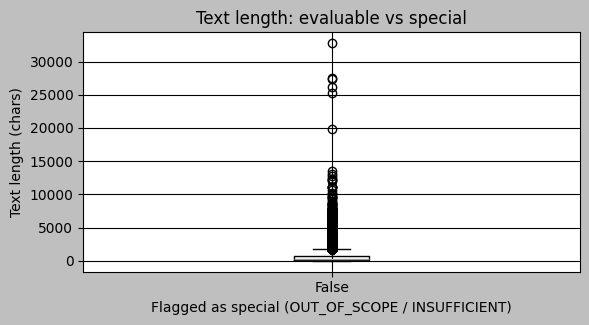

In [8]:
# Text length comparison: special vs evaluable
df["text_len"] = df[TEXT_COL].str.len()
df["is_special"] = df[AI_COL].isin(SPECIAL_LABELS)

summary = df.groupby("is_special")["text_len"].describe()
print("Text length by scope status (is_special=True means OUT_OF_SCOPE/INSUFFICIENT):")
print(summary.round(1))

fig, ax = plt.subplots(figsize=(6, 3.5))
df.boxplot(column="text_len", by="is_special", ax=ax)
ax.set_xlabel("Flagged as special (OUT_OF_SCOPE / INSUFFICIENT)")
ax.set_ylabel("Text length (chars)")
ax.set_title("Text length: evaluable vs special")
plt.suptitle("")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "text_length_by_scope.png"), dpi=300)
plt.show()

# 2. Label Distribution (Original vs AI)

Rows with valid human AND AI labels: 53043

Original label distribution:
human_label
Normal                  16351
Depression              15404
Anxiety                  3888
Suicidal                10653
Stress                   2669
Bipolar                  2877
Personality Disorder     1201
Name: count, dtype: int64

AI label distribution:
ai_label
Normal                  19921
Depression               9688
Anxiety                  7550
Suicidal                12145
Stress                   2119
Bipolar                  1213
Personality Disorder      407
Name: count, dtype: int64


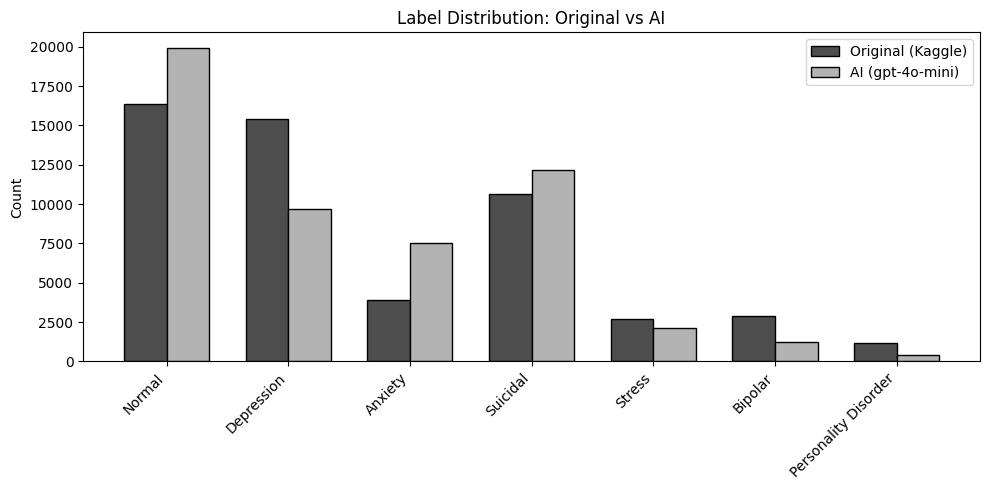

In [9]:
# Filter to rows where BOTH labels are valid 7-class
df_valid = df.dropna(subset=["human_label", "ai_label"]).copy()
print(f"Rows with valid human AND AI labels: {len(df_valid)}")

counts_h = df_valid["human_label"].value_counts().reindex(LABELS, fill_value=0)
counts_a = df_valid["ai_label"].value_counts().reindex(LABELS, fill_value=0)

print("\nOriginal label distribution:")
print(counts_h)
print("\nAI label distribution:")
print(counts_a)

# Side-by-side bar plot
x = np.arange(len(LABELS))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, counts_h, width, label="Original (Kaggle)", color="0.3", edgecolor="black")
ax.bar(x + width/2, counts_a, width, label="AI (gpt-4o-mini)", color="0.7", edgecolor="black")
ax.set_xticks(x)
ax.set_xticklabels(LABELS, rotation=45, ha="right")
ax.set_ylabel("Count")
ax.set_title("Label Distribution: Original vs AI")
ax.legend()
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "label_distribution_original_vs_ai.png"), dpi=300)
plt.show()

# 3. Confusion Matrix, Classification Report & Cohen's Kappa

In [10]:
def plot_confusion_matrix_counts_and_pct(
    y_row, y_col, labels, row_name="Rater A", col_name="Rater B",
    title="Confusion matrix", figsize=(7, 6), save_path=None, dpi=300,
):
    cm = confusion_matrix(y_row, y_col, labels=labels)
    total = cm.sum()
    annot = np.empty_like(cm, dtype=object)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            count = cm[i, j]
            pct = 100.0 * count / total if total > 0 else 0.0
            annot[i, j] = f"{count}\n({pct:.1f}%)"

    plt.figure(figsize=figsize)
    ax = sns.heatmap(
        cm, annot=annot, fmt="", cmap="Greys",
        xticklabels=labels, yticklabels=labels,
        vmin=0, cbar=False,
    )
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    plt.xlabel(col_name)
    plt.ylabel(row_name)
    plt.title(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=dpi)
        print(f"Saved → {save_path}")
    plt.show()
    plt.close()
    return cm

Saved → ./00_Labelling/figures_exploration/cm_original_vs_ai.png


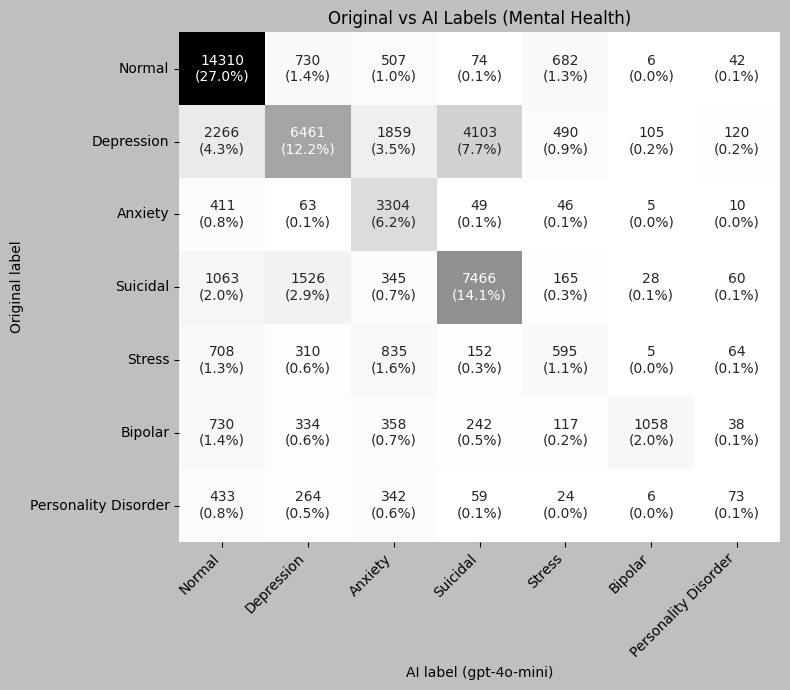

In [11]:
y_human = df_valid["human_label"]
y_ai    = df_valid["ai_label"]

cm = plot_confusion_matrix_counts_and_pct(
    y_row=y_human, y_col=y_ai, labels=LABELS,
    row_name="Original label",
    col_name="AI label (gpt-4o-mini)",
    title="Original vs AI Labels (Mental Health)",
    figsize=(8, 7),
    save_path=os.path.join(FIGURE_DIR, "cm_original_vs_ai.png"),
)

In [12]:
# Classification report (treating original as ground truth)
print("=== Classification Report (Original = truth, AI = prediction) ===")
print(classification_report(y_human, y_ai, labels=LABELS, digits=4, zero_division=0))

# Overall agreement
n_total = len(df_valid)
n_agree = (y_human == y_ai).sum()
print(f"Exact agreement: {n_agree}/{n_total} ({n_agree/n_total:.1%})")

# Cohen's kappa
kappa = cohen_kappa_score(y_human, y_ai)
print(f"Cohen's kappa: {kappa:.4f}")

# Bootstrap CI for kappa
n_boot = 1000
rng = np.random.default_rng(2025)
indices = np.arange(n_total)
boot_kappa = []
for _ in range(n_boot):
    idx = rng.choice(indices, size=n_total, replace=True)
    boot_kappa.append(cohen_kappa_score(y_human.values[idx], y_ai.values[idx]))
boot_kappa = np.array(boot_kappa)
ci_lo, ci_hi = np.percentile(boot_kappa, [2.5, 97.5])
print(f"Bootstrap 95% CI for kappa: ({ci_lo:.4f}, {ci_hi:.4f})")

=== Classification Report (Original = truth, AI = prediction) ===
                      precision    recall  f1-score   support

              Normal     0.7183    0.8752    0.7890     16351
          Depression     0.6669    0.4194    0.5150     15404
             Anxiety     0.4376    0.8498    0.5777      3888
            Suicidal     0.6147    0.7008    0.6550     10653
              Stress     0.2808    0.2229    0.2485      2669
             Bipolar     0.8722    0.3677    0.5174      2877
Personality Disorder     0.1794    0.0608    0.0908      1201

            accuracy                         0.6272     53043
           macro avg     0.5386    0.4995    0.4848     53043
        weighted avg     0.6361    0.6272    0.6093     53043

Exact agreement: 33267/53043 (62.7%)
Cohen's kappa: 0.5167
Bootstrap 95% CI for kappa: (0.5116, 0.5218)


In [13]:
# Per-class agreement rate
print("\n=== Per-class agreement rate ===")
for label in LABELS:
    mask = y_human == label
    n_class = mask.sum()
    n_agree_class = ((y_human == label) & (y_ai == label)).sum()
    rate = n_agree_class / n_class if n_class > 0 else 0
    print(f"  {label:25s}  {n_agree_class:>5}/{n_class:<5}  ({rate:.1%})")


=== Per-class agreement rate ===
  Normal                     14310/16351  (87.5%)
  Depression                  6461/15404  (41.9%)
  Anxiety                     3304/3888   (85.0%)
  Suicidal                    7466/10653  (70.1%)
  Stress                       595/2669   (22.3%)
  Bipolar                     1058/2877   (36.8%)
  Personality Disorder          73/1201   (6.1%)


# 4. Entropy from Soft Probability Labels

In [14]:
# Ensure probability columns are numeric
for col in PROB_COLS:
    df_valid[col] = pd.to_numeric(df_valid[col], errors="coerce")

P = df_valid[PROB_COLS].values
K = P.shape[1]

# Normalize rows and compute raw Shannon entropy (nats)
eps = 1e-12
P_safe = np.clip(P, eps, 1.0)
P_safe = P_safe / P_safe.sum(axis=1, keepdims=True)
entropy = -np.sum(P_safe * np.log(P_safe), axis=1)  # raw entropy in nats; max = ln(K) ≈ 1.95
df_valid["ai_entropy"] = entropy

print(f"AI entropy (raw, nats; max = ln({K}) = {np.log(K):.4f}) statistics:")
print(df_valid["ai_entropy"].describe().round(4))

AI entropy (raw, nats; max = ln(7) = 1.9459) statistics:
count    53043.0000
mean         0.2539
std          0.3131
min          0.0000
25%          0.0000
50%          0.0000
75%          0.5004
max          1.8462
Name: ai_entropy, dtype: float64


N total: 53043
N zero-entropy: 27890 (52.6%)
N positive:     25153


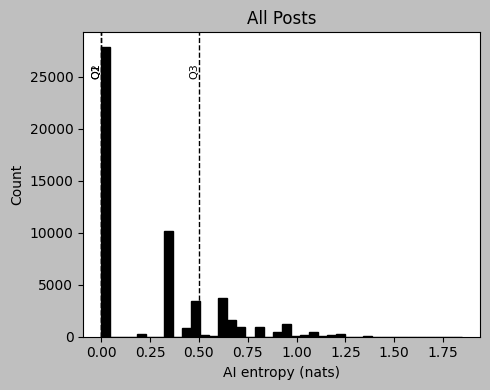

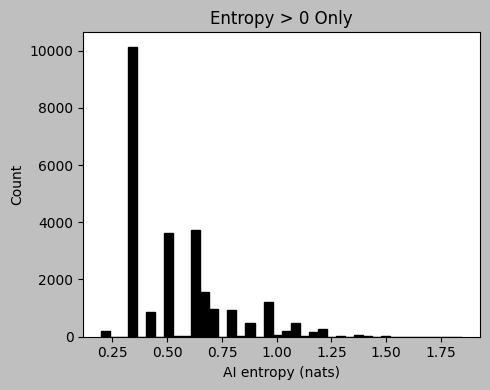

In [15]:
# --- Panel (a): All Posts ---
ent = df_valid["ai_entropy"].to_numpy()
ent = np.clip(ent, 0, None)

is_zero = ent < 1e-6
print(f"N total: {len(ent)}")
print(f"N zero-entropy: {is_zero.sum()} ({is_zero.mean():.1%})")
print(f"N positive:     {(~is_zero).sum()}")

qs = np.quantile(ent, [0.25, 0.5, 0.75])

fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(ent, bins=40, edgecolor="black")
ax.set_xlabel("AI entropy (nats)")
ax.set_ylabel("Count")
ax.set_title("All Posts")
for v, lab in zip(qs, ["Q1", "Q2", "Q3"]):
    ax.axvline(v, ls="--", lw=1)
    ax.text(v, ax.get_ylim()[1]*0.9, lab, rotation=90, va="top", ha="right", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "entropy_all.png"), dpi=300, bbox_inches="tight")
plt.show()

# --- Panel (b): Entropy > 0 Only ---
ent_pos = ent[~is_zero]

fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(ent_pos, bins=40, edgecolor="black")
ax.set_xlabel("AI entropy (nats)")
ax.set_ylabel("Count")
ax.set_title("Entropy > 0 Only")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "entropy_pos.png"), dpi=300, bbox_inches="tight")
plt.show()

Entropy by original label:
                          n    mean     std  median     q25     q75
human_label                                                        
Normal                16351  0.1643  0.2394  0.0000  0.0000  0.3251
Depression            15404  0.3208  0.3375  0.3251  0.0000  0.6109
Anxiety                3888  0.3896  0.2515  0.3251  0.3251  0.5004
Suicidal              10653  0.2142  0.2909  0.0000  0.0000  0.3251
Stress                 2669  0.3018  0.3814  0.0000  0.0000  0.6109
Bipolar                2877  0.2649  0.3949  0.0000  0.0000  0.6109
Personality Disorder   1201  0.3970  0.4119  0.3251  0.0000  0.6730


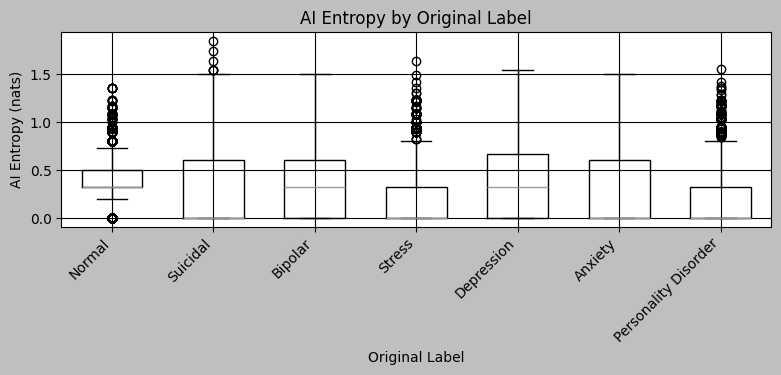

In [16]:
# Entropy by original human label
entropy_by_status = (
    df_valid
    .groupby("human_label")["ai_entropy"]
    .agg(n="size", mean="mean", std="std", median="median",
         q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75))
    .reindex(LABELS)
    .round(4)
)
print("Entropy by original label:")
print(entropy_by_status)

# Box plot
fig, ax = plt.subplots(figsize=(8, 4))
order = entropy_by_status.sort_values("mean").index.tolist()
df_valid.boxplot(column="ai_entropy", by="human_label", ax=ax,
                 positions=range(len(order)),
                 widths=0.6)
ax.set_xticklabels(order, rotation=45, ha="right")
ax.set_xlabel("Original Label")
ax.set_ylabel("AI Entropy (nats)")
ax.set_title("AI Entropy by Original Label")
plt.suptitle("")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "entropy_by_original_label.png"), dpi=300)
plt.show()

# 5. Entropy vs Human–AI Disagreement

Disagreement rate by entropy quintile:
                              entropy_bin  disagree
0  (-9.982821379999999e-08, 1.717864e-10]  0.454093
1            (1.717864e-10, 1.717867e-10]  0.301767
2                (1.717867e-10, 0.325083]  0.224477
3                   (0.325083, 0.5004024]  0.362175
4                  (0.5004024, 1.8462202]  0.550439


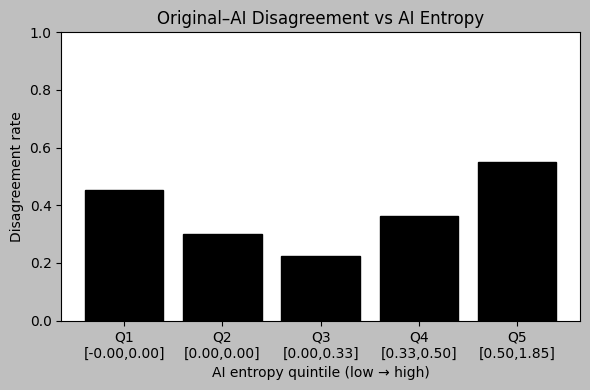

In [17]:
df_valid = df_valid.copy()
df_valid["disagree"] = (df_valid["human_label"] != df_valid["ai_label"]).astype(int)

# Disagreement by entropy quintile
df_valid["entropy_bin"] = pd.qcut(df_valid["ai_entropy"], q=5, duplicates="drop")
disagree_by_bin = (
    df_valid.groupby("entropy_bin", observed=False)["disagree"]
    .mean().reset_index()
)
print("Disagreement rate by entropy quintile:")
print(disagree_by_bin)

# Plot
labels_q = [f"Q{i+1}\n[{row.entropy_bin.left:.2f},{row.entropy_bin.right:.2f}]"
            for i, row in disagree_by_bin.iterrows()]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(range(len(disagree_by_bin)), disagree_by_bin["disagree"], edgecolor="black")
ax.set_xticks(range(len(disagree_by_bin)))
ax.set_xticklabels(labels_q)
ax.set_ylim(0, 1)
ax.set_ylabel("Disagreement rate")
ax.set_xlabel("AI entropy quintile (low → high)")
ax.set_title("Original–AI Disagreement vs AI Entropy")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "disagreement_vs_entropy.png"), dpi=300)
plt.show()

Entropy distribution by agreement:
            count    mean     std  min  25%  50%     75%     max
disagree                                                        
0         33267.0  0.2218  0.2761  0.0  0.0  0.0  0.3251  1.8462
1         19776.0  0.3079  0.3605  0.0  0.0  0.0  0.6109  1.7481


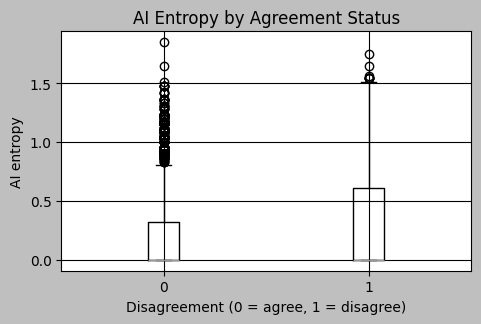

In [18]:
# Entropy distribution: agree vs disagree
entropy_by_agree = (
    df_valid.groupby("disagree")["ai_entropy"]
    .describe(percentiles=[0.25, 0.5, 0.75])
)
print("Entropy distribution by agreement:")
print(entropy_by_agree.round(4))

fig, ax = plt.subplots(figsize=(5, 3.5))
df_valid.boxplot(column="ai_entropy", by="disagree", ax=ax)
ax.set_xlabel("Disagreement (0 = agree, 1 = disagree)")
ax.set_ylabel("AI entropy")
ax.set_title("AI Entropy by Agreement Status")
plt.suptitle("")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "entropy_by_agreement.png"), dpi=300)
plt.show()

# 6. High-Uncertainty Subset for Review

In [19]:
threshold = df_valid["ai_entropy"].quantile(0.8)
high_unc = df_valid[df_valid["ai_entropy"] >= threshold]

print(f"Entropy threshold (80th pct): {threshold:.4f}")
print(f"High-uncertainty rows: {len(high_unc)}")
print(f"Disagreement rate (high-unc): {high_unc['disagree'].mean():.3f}")
print(f"Disagreement rate (all):      {df_valid['disagree'].mean():.3f}")

# Which classes are most affected?
print("\nHigh-uncertainty rows by original label:")
print(high_unc["human_label"].value_counts().reindex(LABELS, fill_value=0))

Entropy threshold (80th pct): 0.5004
High-uncertainty rows: 10932
Disagreement rate (high-unc): 0.545
Disagreement rate (all):      0.373

High-uncertainty rows by original label:
human_label
Normal                  1265
Depression              4710
Anxiety                  887
Suicidal                2046
Stress                   751
Bipolar                  758
Personality Disorder     515
Name: count, dtype: int64


# 7. Logistic Regression: Predicting Disagreement

In [20]:
import statsmodels.formula.api as smf
from sklearn.metrics import roc_auc_score

df_lr = df_valid.copy()
df_lr = df_lr.dropna(subset=["ai_entropy", "human_label"]).copy()

# Standardize entropy
ent_mean = df_lr["ai_entropy"].mean()
ent_std  = df_lr["ai_entropy"].std()
df_lr["entropy_std"] = (df_lr["ai_entropy"] - ent_mean) / ent_std
df_lr["human_label"] = df_lr["human_label"].astype("category")

y = df_lr["disagree"].values

# Model 1: disagree ~ entropy
model1 = smf.logit("disagree ~ entropy_std", data=df_lr).fit(disp=0)
print("=== Model 1: disagree ~ entropy_std ===")
print(model1.summary2())

or1 = np.exp(model1.params)
ci1 = np.exp(model1.conf_int())
print("\nOdds ratios:")
print(pd.DataFrame({"OR": or1, "CI_low": ci1[0], "CI_high": ci1[1]}).round(4))

auc1 = roc_auc_score(y, model1.predict(df_lr))
print(f"AUC: {auc1:.4f}")

# Model 2: disagree ~ entropy + original label
formula2 = "disagree ~ entropy_std + C(human_label, Treatment(reference='Normal'))"
model2 = smf.logit(formula2, data=df_lr).fit(disp=0)
print("\n=== Model 2: disagree ~ entropy_std + human_label ===")
print(model2.summary2())

or2 = np.exp(model2.params)
ci2 = np.exp(model2.conf_int())
print("\nOdds ratios:")
print(pd.DataFrame({"OR": or2, "CI_low": ci2[0], "CI_high": ci2[1]}).round(4))

auc2 = roc_auc_score(y, model2.predict(df_lr))
print(f"AUC: {auc2:.4f}")

=== Model 1: disagree ~ entropy_std ===
                          Results: Logit
Model:              Logit            Method:           MLE        
Dependent Variable: disagree         Pseudo R-squared: 0.013      
Date:               2026-03-18 23:26 AIC:              69143.5473 
No. Observations:   53043            BIC:              69161.3050 
Df Model:           1                Log-Likelihood:   -34570.    
Df Residuals:       53041            LL-Null:          -35032.    
Converged:          1.0000           LLR p-value:      4.9551e-203
No. Iterations:     4.0000           Scale:            1.0000     
-------------------------------------------------------------------
               Coef.   Std.Err.     z      P>|z|    [0.025   0.975]
-------------------------------------------------------------------
Intercept     -0.5279    0.0091  -58.1962  0.0000  -0.5457  -0.5102
entropy_std    0.2707    0.0089   30.3106  0.0000   0.2532   0.2882


Odds ratios:
                 OR  CI_low 

# 8. AI Probability Calibration

Expected Calibration Error (ECE): 0.2701


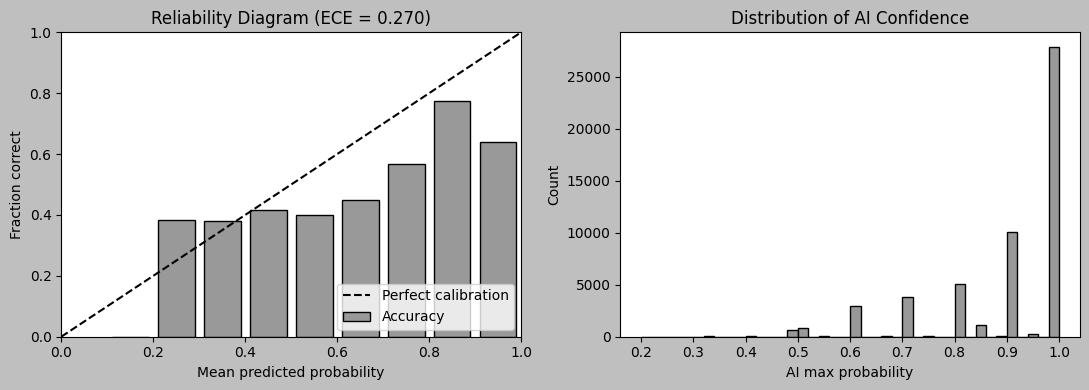

In [21]:
# Reliability diagram: Is the AI's max probability well-calibrated?
max_prob = P_safe.max(axis=1)
correct  = (df_valid["human_label"] == df_valid["ai_label"]).astype(int).values

n_bins = 10
bin_edges = np.linspace(0, 1, n_bins + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

acc_per_bin = []
conf_per_bin = []
count_per_bin = []

for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
    mask = (max_prob >= lo) & (max_prob < hi)
    if mask.sum() == 0:
        acc_per_bin.append(np.nan)
        conf_per_bin.append(np.nan)
        count_per_bin.append(0)
    else:
        acc_per_bin.append(correct[mask].mean())
        conf_per_bin.append(max_prob[mask].mean())
        count_per_bin.append(mask.sum())

acc_per_bin = np.array(acc_per_bin)
conf_per_bin = np.array(conf_per_bin)
count_per_bin = np.array(count_per_bin)

# Expected Calibration Error
valid_bins = count_per_bin > 0
ece = np.sum(count_per_bin[valid_bins] * np.abs(acc_per_bin[valid_bins] - conf_per_bin[valid_bins])) / count_per_bin.sum()
print(f"Expected Calibration Error (ECE): {ece:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Reliability diagram
ax = axes[0]
ax.bar(bin_centers, acc_per_bin, width=0.08, edgecolor="black", color="0.6", label="Accuracy")
ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction correct")
ax.set_title(f"Reliability Diagram (ECE = {ece:.3f})")
ax.legend(loc="lower right")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Confidence histogram
ax2 = axes[1]
ax2.hist(max_prob, bins=40, edgecolor="black", color="0.6")
ax2.set_xlabel("AI max probability")
ax2.set_ylabel("Count")
ax2.set_title("Distribution of AI Confidence")

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "calibration.png"), dpi=300)
plt.show()

# 9. Condition Strength vs Agreement

Disagreement rate and entropy by condition strength:
           condition strength     n  disagree_rate  mean_entropy
          depression     none 32447       0.355811      0.204643
          depression     weak  2726       0.554292      0.473964
          depression    clear 17870       0.376049      0.309849
             anxiety     none 41826       0.334385      0.212765
             anxiety     weak  1778       0.415636      0.439370
             anxiety    clear  9439       0.535120      0.401393
            suicidal     none 39832       0.367042      0.257406
            suicidal     weak   900       0.443333      0.452308
            suicidal    clear 12311       0.386402      0.228170
              stress     none 42864       0.341522      0.202097
              stress     weak  5887       0.446407      0.584412
              stress    clear  4292       0.584576      0.318252
             bipolar     none 51190       0.374077      0.251120
             bipolar     weak   448  

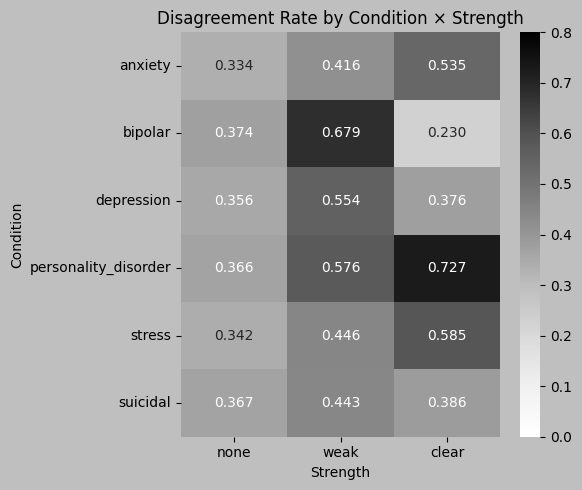

In [22]:
# For each condition, check if strength (none/weak/clear) correlates with agreement
conditions = ["depression", "anxiety", "suicidal", "stress", "bipolar", "personality_disorder"]

strength_data = []
for cond in conditions:
    strength_col = f"u_{cond}_strength"
    if strength_col not in df_valid.columns:
        continue
    for strength in ["none", "weak", "clear"]:
        mask = df_valid[strength_col] == strength
        if mask.sum() == 0:
            continue
        n = mask.sum()
        disagree_rate = df_valid.loc[mask, "disagree"].mean()
        mean_entropy = df_valid.loc[mask, "ai_entropy"].mean()
        strength_data.append({
            "condition": cond, "strength": strength,
            "n": n, "disagree_rate": disagree_rate,
            "mean_entropy": mean_entropy,
        })

df_strength = pd.DataFrame(strength_data)
print("Disagreement rate and entropy by condition strength:")
print(df_strength.to_string(index=False))

# Pivot for heatmap
pivot_disagree = df_strength.pivot(index="condition", columns="strength", values="disagree_rate")
pivot_disagree = pivot_disagree[["none", "weak", "clear"]]

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(pivot_disagree, annot=True, fmt=".3f", cmap="Greys", ax=ax,
            vmin=0, vmax=pivot_disagree.max().max() * 1.1)
ax.set_title("Disagreement Rate by Condition × Strength")
ax.set_xlabel("Strength")
ax.set_ylabel("Condition")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "strength_vs_disagreement.png"), dpi=300)
plt.show()

# 10. Disagreement Pattern Analysis

Total disagreement rows: 19776

Transition matrix (Original → AI, disagreements only):
ai_label              Normal  Depression  Anxiety  Suicidal  Stress  Bipolar  \
human_label                                                                    
Normal                     0         730      507        74     682        6   
Depression              2266           0     1859      4103     490      105   
Anxiety                  411          63        0        49      46        5   
Suicidal                1063        1526      345         0     165       28   
Stress                   708         310      835       152       0        5   
Bipolar                  730         334      358       242     117        0   
Personality Disorder     433         264      342        59      24        6   
All                     5611        3227     4246      4679    1524      155   

ai_label              Personality Disorder    All  
human_label                                        
Normal  

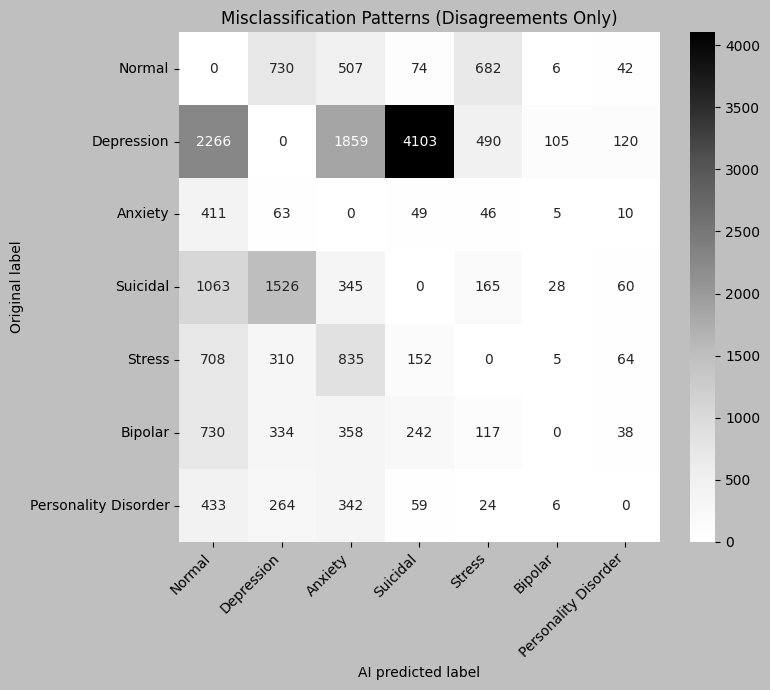

In [23]:
# When AI disagrees, what does it predict instead?
disagree_df = df_valid[df_valid["disagree"] == 1].copy()
print(f"Total disagreement rows: {len(disagree_df)}")

# Transition matrix: Original → AI (for disagreements only)
trans = pd.crosstab(
    disagree_df["human_label"], disagree_df["ai_label"],
    margins=True
).reindex(index=LABELS + ["All"], columns=LABELS + ["All"], fill_value=0)
print("\nTransition matrix (Original → AI, disagreements only):")
print(trans)

# Heatmap of misclassification patterns
trans_core = trans.loc[LABELS, LABELS]
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(trans_core, annot=True, fmt="d", cmap="Greys", ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_xlabel("AI predicted label")
ax.set_ylabel("Original label")
ax.set_title("Misclassification Patterns (Disagreements Only)")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "misclassification_patterns.png"), dpi=300)
plt.show()

In [24]:
# Most common confusion pairs
pairs = []
for orig in LABELS:
    for ai in LABELS:
        if orig == ai:
            continue
        n = ((disagree_df["human_label"] == orig) & (disagree_df["ai_label"] == ai)).sum()
        if n > 0:
            pairs.append({"Original": orig, "AI_predicted": ai, "Count": n})

df_pairs = pd.DataFrame(pairs).sort_values("Count", ascending=False)
print("Top 15 confusion pairs:")
print(df_pairs.head(15).to_string(index=False))

Top 15 confusion pairs:
            Original AI_predicted  Count
          Depression     Suicidal   4103
          Depression       Normal   2266
          Depression      Anxiety   1859
            Suicidal   Depression   1526
            Suicidal       Normal   1063
              Stress      Anxiety    835
             Bipolar       Normal    730
              Normal   Depression    730
              Stress       Normal    708
              Normal       Stress    682
              Normal      Anxiety    507
          Depression       Stress    490
Personality Disorder       Normal    433
             Anxiety       Normal    411
             Bipolar      Anxiety    358


# 11. Summary

In [25]:
print("=" * 60)
print("SUMMARY — Original vs AI Label Analysis (Mental Health)")
print("=" * 60)
print(f"  Total rows:                  {len(df)}")
print(f"  Evaluable (both labels):     {len(df_valid)}")
print(f"  Special (OUT_OF_SCOPE/INSUFFICIENT): {df[AI_COL].isin(SPECIAL_LABELS).sum()}")
print(f"")
print(f"  Exact agreement:             {(df_valid['disagree']==0).sum()}/{len(df_valid)} "
      f"({(df_valid['disagree']==0).mean():.1%})")
print(f"  Cohen's kappa:               {kappa:.4f} (95% CI: {ci_lo:.4f}–{ci_hi:.4f})")
print(f"  Expected Calibration Error:  {ece:.4f}")
print(f"")
print(f"  High-uncertainty (top 20%):  {len(high_unc)} rows")
print(f"    Disagree rate (high-unc):  {high_unc['disagree'].mean():.3f}")
print(f"    Disagree rate (overall):   {df_valid['disagree'].mean():.3f}")
print(f"")
print(f"  Logistic regression AUC:")
print(f"    Model 1 (entropy only):    {auc1:.4f}")
print(f"    Model 2 (entropy + label): {auc2:.4f}")

SUMMARY — Original vs AI Label Analysis (Mental Health)
  Total rows:                  53043
  Evaluable (both labels):     53043
  Special (OUT_OF_SCOPE/INSUFFICIENT): 0

  Exact agreement:             33267/53043 (62.7%)
  Cohen's kappa:               0.5167 (95% CI: 0.5116–0.5218)
  Expected Calibration Error:  0.2701

  High-uncertainty (top 20%):  10932 rows
    Disagree rate (high-unc):  0.545
    Disagree rate (overall):   0.373

  Logistic regression AUC:
    Model 1 (entropy only):    0.5297
    Model 2 (entropy + label): 0.7769


# 12. Comorbidity Analysis — Prevalence & Co-occurrence

=== Distribution of number of co-occurring conditions ===
  0 conditions:  17463 ( 32.9%)
  1 conditions:  17893 ( 33.7%)
  2 conditions:  13514 ( 25.5%)
  3 conditions:   3384 (  6.4%)
  4 conditions:    723 (  1.4%)
  5 conditions:     59 (  0.1%)
  6 conditions:      7 (  0.0%)

  Mean: 1.10
  Rows with 0 conditions (Normal-inferred): 17463
  Rows with 1 condition (single-label):     17893
  Rows with 2+ conditions (comorbid):       17687 (33.3%)


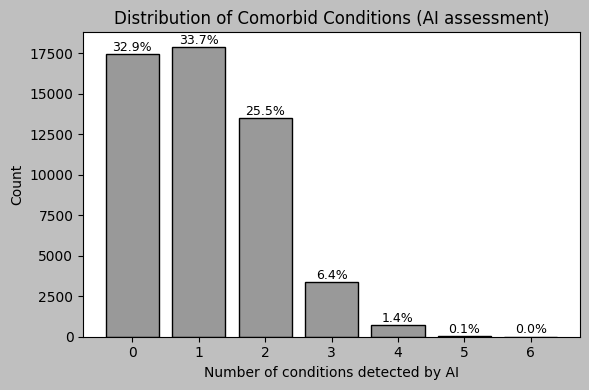

In [26]:
# --- 12a. Number of co-occurring conditions ---
CONDITION_COLS = [
    "u_depression_present", "u_anxiety_present", "u_suicidal_present",
    "u_stress_present", "u_bipolar_present", "u_personality_disorder_present",
]
CONDITION_NAMES = ["Depression", "Anxiety", "Suicidal", "Stress", "Bipolar", "Pers. Disorder"]

# u_n_conditions is already in the dataset; verify it matches sum of _present cols
df_valid["n_conditions_check"] = df_valid[CONDITION_COLS].sum(axis=1).astype(int)
assert (df_valid["n_conditions_check"] == df_valid["u_n_conditions"]).all(), \
    "n_conditions mismatch!"
df_valid["n_cond"] = df_valid["u_n_conditions"].astype(int)

# Distribution
cond_dist = df_valid["n_cond"].value_counts().sort_index()
print("=== Distribution of number of co-occurring conditions ===")
for n, count in cond_dist.items():
    pct = count / len(df_valid) * 100
    print(f"  {n} conditions: {count:>6} ({pct:5.1f}%)")

print(f"\n  Mean: {df_valid['n_cond'].mean():.2f}")
print(f"  Rows with 0 conditions (Normal-inferred): {(df_valid['n_cond'] == 0).sum()}")
print(f"  Rows with 1 condition (single-label):     {(df_valid['n_cond'] == 1).sum()}")
print(f"  Rows with 2+ conditions (comorbid):       {(df_valid['n_cond'] >= 2).sum()} "
      f"({(df_valid['n_cond'] >= 2).mean():.1%})")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(cond_dist.index, cond_dist.values, edgecolor="black", color="0.6")
ax.set_xlabel("Number of conditions detected by AI")
ax.set_ylabel("Count")
ax.set_title("Distribution of Comorbid Conditions (AI assessment)")
for i, (n, count) in enumerate(cond_dist.items()):
    ax.text(n, count + 200, f"{count/len(df_valid)*100:.1f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "comorbidity_n_conditions.png"), dpi=300)
plt.show()

=== Per-condition prevalence (AI assessment) ===
  Depression             20597  ( 38.8%)
  Anxiety                11217  ( 21.1%)
  Suicidal               13211  ( 24.9%)
  Stress                 10179  ( 19.2%)
  Bipolar                 1853  (  3.5%)
  Pers. Disorder          1245  (  2.3%)

=== Comorbidity rate by original human label ===
                          n  mean_n_cond  pct_comorbid  pct_zero
human_label                                                     
Normal                16351        0.207         0.013     0.806
Depression            15404        1.535         0.496     0.100
Anxiety                3888        1.287         0.324     0.085
Suicidal              10653        1.640         0.567     0.076
Stress                 2669        1.155         0.308     0.221
Bipolar                2877        1.463         0.433     0.212
Personality Disorder   1201        1.256         0.396     0.324


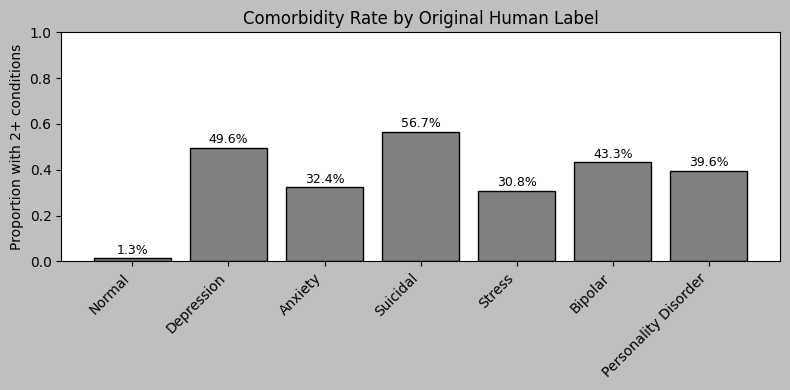

In [27]:
# --- 12b. Per-condition prevalence ---
print("=== Per-condition prevalence (AI assessment) ===")
for col, name in zip(CONDITION_COLS, CONDITION_NAMES):
    n_present = df_valid[col].sum()
    pct = n_present / len(df_valid) * 100
    print(f"  {name:20s}  {n_present:>6}  ({pct:5.1f}%)")

# Comorbidity rate by original human label
print("\n=== Comorbidity rate by original human label ===")
comorbid_by_label = (
    df_valid.groupby("human_label")
    .agg(
        n=("n_cond", "size"),
        mean_n_cond=("n_cond", "mean"),
        pct_comorbid=("n_cond", lambda x: (x >= 2).mean()),
        pct_zero=("n_cond", lambda x: (x == 0).mean()),
    )
    .reindex(LABELS)
    .round(3)
)
print(comorbid_by_label)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(LABELS))
ax.bar(x, comorbid_by_label["pct_comorbid"], edgecolor="black", color="0.5")
ax.set_xticks(x)
ax.set_xticklabels(LABELS, rotation=45, ha="right")
ax.set_ylabel("Proportion with 2+ conditions")
ax.set_title("Comorbidity Rate by Original Human Label")
ax.set_ylim(0, 1)
for i, v in enumerate(comorbid_by_label["pct_comorbid"]):
    ax.text(i, v + 0.02, f"{v:.1%}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "comorbidity_rate_by_label.png"), dpi=300)
plt.show()

=== Condition co-occurrence matrix (counts) ===
                Depression  Anxiety  Suicidal  Stress  Bipolar  Pers. Disorder
Depression           20597     4424      9610    4367     1022             657
Anxiety               4424    11217      1907    3218      520             357
Suicidal              9610     1907     13211    1291      351             285
Stress                4367     3218      1291   10179      343             239
Bipolar               1022      520       351     343     1853             108
Pers. Disorder         657      357       285     239      108            1245

=== Conditional co-occurrence: P(column | row present) ===
                Depression  Anxiety  Suicidal  Stress  Bipolar  Pers. Disorder
Depression           1.000    0.215     0.467   0.212    0.050           0.032
Anxiety              0.394    1.000     0.170   0.287    0.046           0.032
Suicidal             0.727    0.144     1.000   0.098    0.027           0.022
Stress               0.

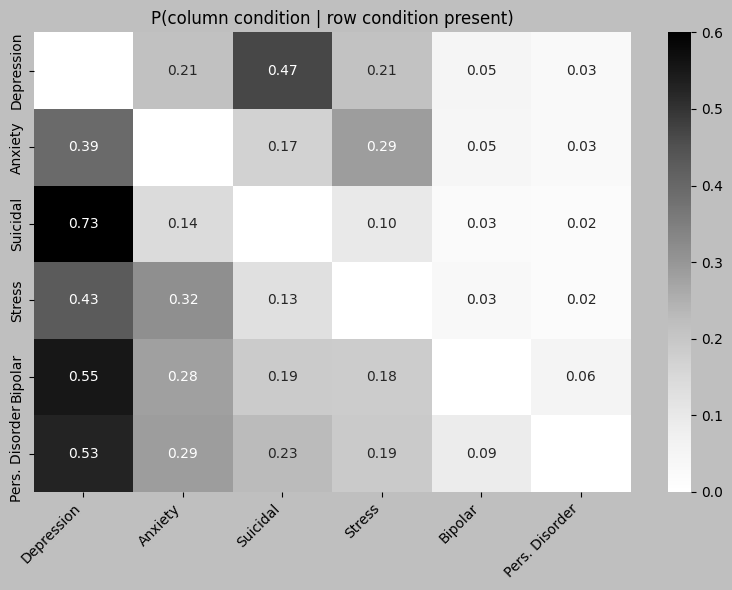

In [28]:
# --- 12c. Condition co-occurrence matrix ---
# Binary matrix: which conditions are present together
present_matrix = df_valid[CONDITION_COLS].values.astype(int)

# Co-occurrence: how often condition i and condition j are both present
n_conditions = len(CONDITION_COLS)
cooccur = np.zeros((n_conditions, n_conditions), dtype=int)
for i in range(n_conditions):
    for j in range(n_conditions):
        cooccur[i, j] = ((present_matrix[:, i] == 1) & (present_matrix[:, j] == 1)).sum()

df_cooccur = pd.DataFrame(cooccur, index=CONDITION_NAMES, columns=CONDITION_NAMES)
print("=== Condition co-occurrence matrix (counts) ===")
print(df_cooccur)

# Conditional probability: P(j present | i present)
print("\n=== Conditional co-occurrence: P(column | row present) ===")
diag = np.diag(cooccur).astype(float)
diag[diag == 0] = 1  # avoid division by zero
cond_prob = cooccur / diag[:, None]
df_cond_prob = pd.DataFrame(cond_prob, index=CONDITION_NAMES, columns=CONDITION_NAMES).round(3)
print(df_cond_prob)

# Heatmap of conditional co-occurrence (mask diagonal)
mask = np.eye(n_conditions, dtype=bool)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    df_cond_prob, annot=True, fmt=".2f", cmap="Greys",
    mask=mask, vmin=0, vmax=0.6, ax=ax,
)
ax.set_title("P(column condition | row condition present)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "comorbidity_cooccurrence_heatmap.png"), dpi=300)
plt.show()

# 13. Comorbidity Drives Label Confusion

=== Comorbidity rate by agreement status ===
  Agree samples:    29.9% comorbid  (n=33267)
  Disagree samples: 39.2% comorbid  (n=19776)
  Overall:          33.3% comorbid

  Mean conditions (agree):    0.98
  Mean conditions (disagree): 1.30

=== Disagreement rate by number of conditions ===
 n_cond     n  disagree_rate
      0 17463       0.244918
      1 17893       0.433018
      2 13514       0.422229
      3  3384       0.484043
      4   723       0.511757
      5    59       0.542373
      6     7       0.714286


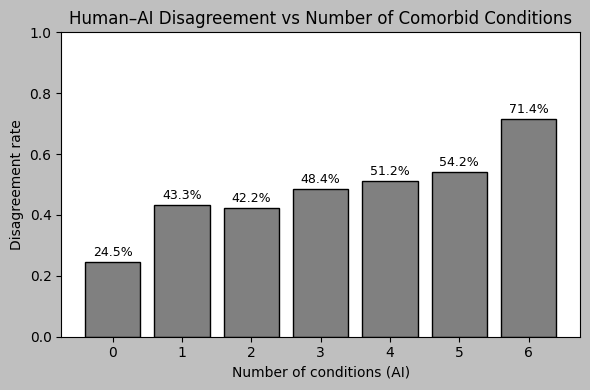

In [29]:
# --- 13a. Comorbidity rate: agree vs disagree ---
df_valid["is_comorbid"] = (df_valid["n_cond"] >= 2).astype(int)

agree_mask = df_valid["disagree"] == 0
disagree_mask = df_valid["disagree"] == 1

comorbid_agree = df_valid.loc[agree_mask, "is_comorbid"].mean()
comorbid_disagree = df_valid.loc[disagree_mask, "is_comorbid"].mean()

print("=== Comorbidity rate by agreement status ===")
print(f"  Agree samples:    {comorbid_agree:.1%} comorbid  (n={agree_mask.sum()})")
print(f"  Disagree samples: {comorbid_disagree:.1%} comorbid  (n={disagree_mask.sum()})")
print(f"  Overall:          {df_valid['is_comorbid'].mean():.1%} comorbid")

# Mean number of conditions
print(f"\n  Mean conditions (agree):    {df_valid.loc[agree_mask, 'n_cond'].mean():.2f}")
print(f"  Mean conditions (disagree): {df_valid.loc[disagree_mask, 'n_cond'].mean():.2f}")

# Disagreement rate by n_conditions
print("\n=== Disagreement rate by number of conditions ===")
disagree_by_ncond = (
    df_valid.groupby("n_cond")["disagree"]
    .agg(n="size", disagree_rate="mean")
    .reset_index()
)
print(disagree_by_ncond.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(disagree_by_ncond["n_cond"], disagree_by_ncond["disagree_rate"],
       edgecolor="black", color="0.5")
ax.set_xlabel("Number of conditions (AI)")
ax.set_ylabel("Disagreement rate")
ax.set_title("Human–AI Disagreement vs Number of Comorbid Conditions")
ax.set_ylim(0, 1)
for _, row in disagree_by_ncond.iterrows():
    ax.text(row["n_cond"], row["disagree_rate"] + 0.02,
            f'{row["disagree_rate"]:.1%}', ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "disagreement_vs_n_conditions.png"), dpi=300)
plt.show()

In [30]:
# --- 13a-ii. Statistical test: comorbidity → disagreement ---
from scipy.stats import chi2_contingency

# 2x2 contingency table: comorbid (yes/no) x disagree (yes/no)
ct = pd.crosstab(df_valid["is_comorbid"], df_valid["disagree"])
print("=== Contingency table: Comorbid × Disagree ===")
ct.index = ["Non-comorbid", "Comorbid"]
ct.columns = ["Agree", "Disagree"]
print(ct)

chi2, p, dof, expected = chi2_contingency(ct)
print(f"\nChi-squared = {chi2:.2f}, df = {dof}, p = {p:.2e}")

# Odds ratio with 95% CI
a, b = ct.iloc[1, 1], ct.iloc[1, 0]  # comorbid: disagree, agree
c, d = ct.iloc[0, 1], ct.iloc[0, 0]  # non-comorbid: disagree, agree
OR = (a * d) / (b * c)
log_OR = np.log(OR)
SE_log_OR = np.sqrt(1/a + 1/b + 1/c + 1/d)
ci_lo_or = np.exp(log_OR - 1.96 * SE_log_OR)
ci_hi_or = np.exp(log_OR + 1.96 * SE_log_OR)

print(f"\nOdds Ratio (comorbid → disagree): {OR:.3f} (95% CI: {ci_lo_or:.3f}–{ci_hi_or:.3f})")
print(f"Interpretation: Comorbid samples have {OR:.1f}x the odds of human–AI "
      f"disagreement compared to non-comorbid samples.")

=== Contingency table: Comorbid × Disagree ===
              Agree  Disagree
Non-comorbid  23331     12025
Comorbid       9936      7751

Chi-squared = 484.98, df = 1, p = 1.76e-107

Odds Ratio (comorbid → disagree): 1.514 (95% CI: 1.459–1.571)
Interpretation: Comorbid samples have 1.5x the odds of human–AI disagreement compared to non-comorbid samples.


PANEL C AGREEMENT SUBSET — COMORBIDITY PROFILE

Full dataset:       N = 53,043
Agreement subset:   N = 33,267 (62.7%)
Disagreement subset: N = 19,776 (37.3%)

--- Comorbidity rates ---
  Full dataset:       33.3%
  Agreement subset:   29.9%  (← Panel C training data)
  Disagreement subset: 39.2%  (excluded from Panel C)
  Relative depletion:  10.4% fewer comorbid cases in Panel C

--- Mean number of conditions ---
  Full dataset:       1.10
  Agreement subset:   0.98
  Disagreement subset: 1.30

--- Class distribution: Full vs Agreement subset ---
                      Full (%)  Panel C (%)  Δ (pp)
human_label                                        
Anxiety                    7.3          9.9     2.6
Bipolar                    5.4          3.2    -2.2
Depression                29.0         19.4    -9.6
Normal                    30.8         43.0    12.2
Personality Disorder       2.3          0.2    -2.0
Stress                     5.0          1.8    -3.2
Suicidal                  20.1

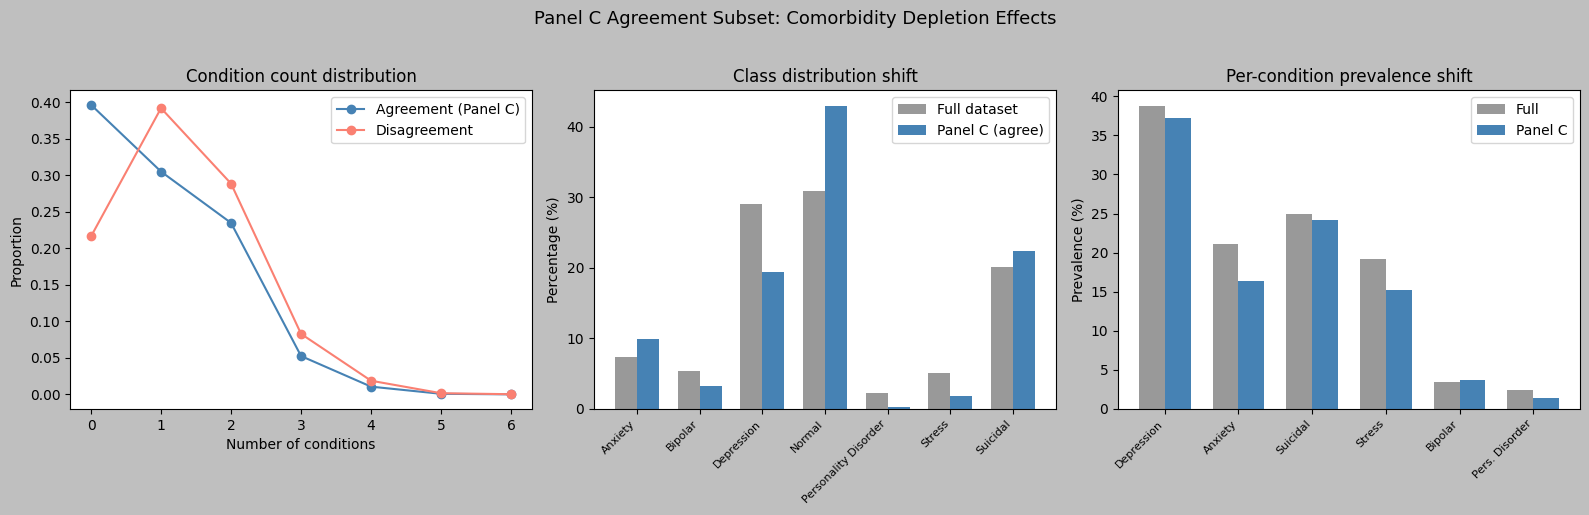


KEY IMPLICATION FOR PANEL C

The agreement subset (Panel C) is systematically depleted of comorbid cases:
  • Comorbid samples disagree more → filtered out by agreement criterion
  • This makes Panel C's training data 'easier' (less ambiguous)
  • Classes most affected by comorbidity (e.g., Depression, Suicidal) lose
    disproportionately more samples in Panel C
  • Panel C performance metrics may appear inflated because the hardest
    cases (comorbid, high-entropy) are excluded from its training data



In [31]:
# --- 13a-iii. Panel C agreement subset: comorbidity profile ---
# Panel C uses only rows where human_label == ai_label (agreement subset).
# Show how filtering to agreement depletes comorbid cases.

agree_sub = df_valid[df_valid["disagree"] == 0].copy()
disagree_sub = df_valid[df_valid["disagree"] == 1].copy()

print("=" * 60)
print("PANEL C AGREEMENT SUBSET — COMORBIDITY PROFILE")
print("=" * 60)

# 1. Basic sizes
print(f"\nFull dataset:       N = {len(df_valid):,}")
print(f"Agreement subset:   N = {len(agree_sub):,} ({len(agree_sub)/len(df_valid):.1%})")
print(f"Disagreement subset: N = {len(disagree_sub):,} ({len(disagree_sub)/len(df_valid):.1%})")

# 2. Comorbidity rates
comorbid_full = df_valid["is_comorbid"].mean()
comorbid_agree = agree_sub["is_comorbid"].mean()
comorbid_disagree = disagree_sub["is_comorbid"].mean()

print(f"\n--- Comorbidity rates ---")
print(f"  Full dataset:       {comorbid_full:.1%}")
print(f"  Agreement subset:   {comorbid_agree:.1%}  (← Panel C training data)")
print(f"  Disagreement subset: {comorbid_disagree:.1%}  (excluded from Panel C)")
print(f"  Relative depletion:  {(comorbid_full - comorbid_agree)/comorbid_full:.1%} fewer comorbid cases in Panel C")

# 3. Mean conditions
print(f"\n--- Mean number of conditions ---")
print(f"  Full dataset:       {df_valid['n_cond'].mean():.2f}")
print(f"  Agreement subset:   {agree_sub['n_cond'].mean():.2f}")
print(f"  Disagreement subset: {disagree_sub['n_cond'].mean():.2f}")

# 4. Class distribution shift
print(f"\n--- Class distribution: Full vs Agreement subset ---")
full_dist = df_valid["human_label"].value_counts(normalize=True).sort_index()
agree_dist = agree_sub["human_label"].value_counts(normalize=True).sort_index()

dist_compare = pd.DataFrame({
    "Full (%)": (full_dist * 100).round(1),
    "Panel C (%)": (agree_dist * 100).round(1),
    "Δ (pp)": ((agree_dist - full_dist) * 100).round(1)
})
print(dist_compare.to_string())

# 5. Per-class comorbidity rates: agreement vs disagreement
print(f"\n--- Per-class comorbidity rate: agree vs disagree ---")
per_class_stats = []
for label in sorted(df_valid["human_label"].unique()):
    mask_label = df_valid["human_label"] == label
    agree_comorbid = df_valid.loc[mask_label & (df_valid["disagree"] == 0), "is_comorbid"].mean()
    disagree_comorbid = df_valid.loc[mask_label & (df_valid["disagree"] == 1), "is_comorbid"].mean()
    n_agree = (mask_label & (df_valid["disagree"] == 0)).sum()
    n_disagree = (mask_label & (df_valid["disagree"] == 1)).sum()
    per_class_stats.append({
        "Class": label,
        "n_agree": n_agree,
        "n_disagree": n_disagree,
        "comorbid_agree": f"{agree_comorbid:.1%}" if n_agree > 0 else "—",
        "comorbid_disagree": f"{disagree_comorbid:.1%}" if n_disagree > 0 else "—"
    })
per_class_df = pd.DataFrame(per_class_stats)
print(per_class_df.to_string(index=False))

# 6. Visualization: side-by-side comorbidity distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) n_conditions distribution
for subset, label, color in [(agree_sub, "Agreement (Panel C)", "steelblue"),
                              (disagree_sub, "Disagreement", "salmon")]:
    counts = subset["n_cond"].value_counts(normalize=True).sort_index()
    axes[0].plot(counts.index, counts.values, "o-", label=label, color=color)
axes[0].set_xlabel("Number of conditions")
axes[0].set_ylabel("Proportion")
axes[0].set_title("Condition count distribution")
axes[0].legend()

# (b) Class distribution
x_pos = np.arange(len(full_dist))
width = 0.35
axes[1].bar(x_pos - width/2, full_dist.values * 100, width, label="Full dataset", color="0.6")
axes[1].bar(x_pos + width/2, agree_dist.values * 100, width, label="Panel C (agree)", color="steelblue")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(full_dist.index, rotation=45, ha="right", fontsize=8)
axes[1].set_ylabel("Percentage (%)")
axes[1].set_title("Class distribution shift")
axes[1].legend()

# (c) Per-condition prevalence: agree vs full
cond_prev_full = df_valid[CONDITION_COLS].mean()
cond_prev_agree = agree_sub[CONDITION_COLS].mean()
x_pos_c = np.arange(len(CONDITION_NAMES))
axes[2].bar(x_pos_c - width/2, cond_prev_full.values * 100, width, label="Full", color="0.6")
axes[2].bar(x_pos_c + width/2, cond_prev_agree.values * 100, width, label="Panel C", color="steelblue")
axes[2].set_xticks(x_pos_c)
axes[2].set_xticklabels(CONDITION_NAMES, rotation=45, ha="right", fontsize=8)
axes[2].set_ylabel("Prevalence (%)")
axes[2].set_title("Per-condition prevalence shift")
axes[2].legend()

plt.suptitle("Panel C Agreement Subset: Comorbidity Depletion Effects", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "panel_c_comorbidity_depletion.png"), dpi=300, bbox_inches="tight")
plt.show()

# 7. Key takeaway
print("\n" + "=" * 60)
print("KEY IMPLICATION FOR PANEL C")
print("=" * 60)
print("""
The agreement subset (Panel C) is systematically depleted of comorbid cases:
  • Comorbid samples disagree more → filtered out by agreement criterion
  • This makes Panel C's training data 'easier' (less ambiguous)
  • Classes most affected by comorbidity (e.g., Depression, Suicidal) lose
    disproportionately more samples in Panel C
  • Panel C performance metrics may appear inflated because the hardest
    cases (comorbid, high-entropy) are excluded from its training data
""")

In [32]:
# --- 13b. Top confusion pairs explained by comorbidity ---
# For the top confusion pairs from Section 10, check what fraction are comorbid
TOP_PAIRS = [
    ("Depression", "Suicidal"),
    ("Depression", "Normal"),
    ("Depression", "Anxiety"),
    ("Suicidal", "Depression"),
    ("Suicidal", "Normal"),
    ("Stress", "Anxiety"),
    ("Bipolar", "Normal"),
    ("Stress", "Normal"),
    ("Bipolar", "Anxiety"),
    ("Personality Disorder", "Normal"),
]

print("=== Top confusion pairs: comorbidity explanation ===")
print(f"{'Original':<22} {'AI predicted':<22} {'N':>5} {'% comorbid':>10} {'Mean n_cond':>11}")
print("-" * 75)
for orig, ai_pred in TOP_PAIRS:
    mask = (df_valid["human_label"] == orig) & (df_valid["ai_label"] == ai_pred)
    n = mask.sum()
    if n == 0:
        continue
    pct_comorbid = df_valid.loc[mask, "is_comorbid"].mean()
    mean_nc = df_valid.loc[mask, "n_cond"].mean()
    print(f"  {orig:<20} {ai_pred:<20} {n:>5} {pct_comorbid:>9.1%} {mean_nc:>11.2f}")

# Compare with matched-label (agree) rows
print(f"\n  {'AGREE samples':<20} {'(all)':<20} {agree_mask.sum():>5} "
      f"{df_valid.loc[agree_mask, 'is_comorbid'].mean():>9.1%} "
      f"{df_valid.loc[agree_mask, 'n_cond'].mean():>11.2f}")

=== Top confusion pairs: comorbidity explanation ===
Original               AI predicted               N % comorbid Mean n_cond
---------------------------------------------------------------------------
  Depression           Suicidal              4103     81.9%        2.08
  Depression           Normal                2266      2.8%        0.35
  Depression           Anxiety               1859     50.3%        1.61
  Suicidal             Depression            1526     44.6%        1.57
  Suicidal             Normal                1063      0.4%        0.24
  Stress               Anxiety                835     48.9%        1.56
  Bipolar              Normal                 730      1.8%        0.18
  Stress               Normal                 708      0.7%        0.17
  Bipolar              Anxiety                358     47.8%        1.68
  Personality Disorder Normal                 433      0.7%        0.11

  AGREE samples        (all)                33267     29.9%        0.98


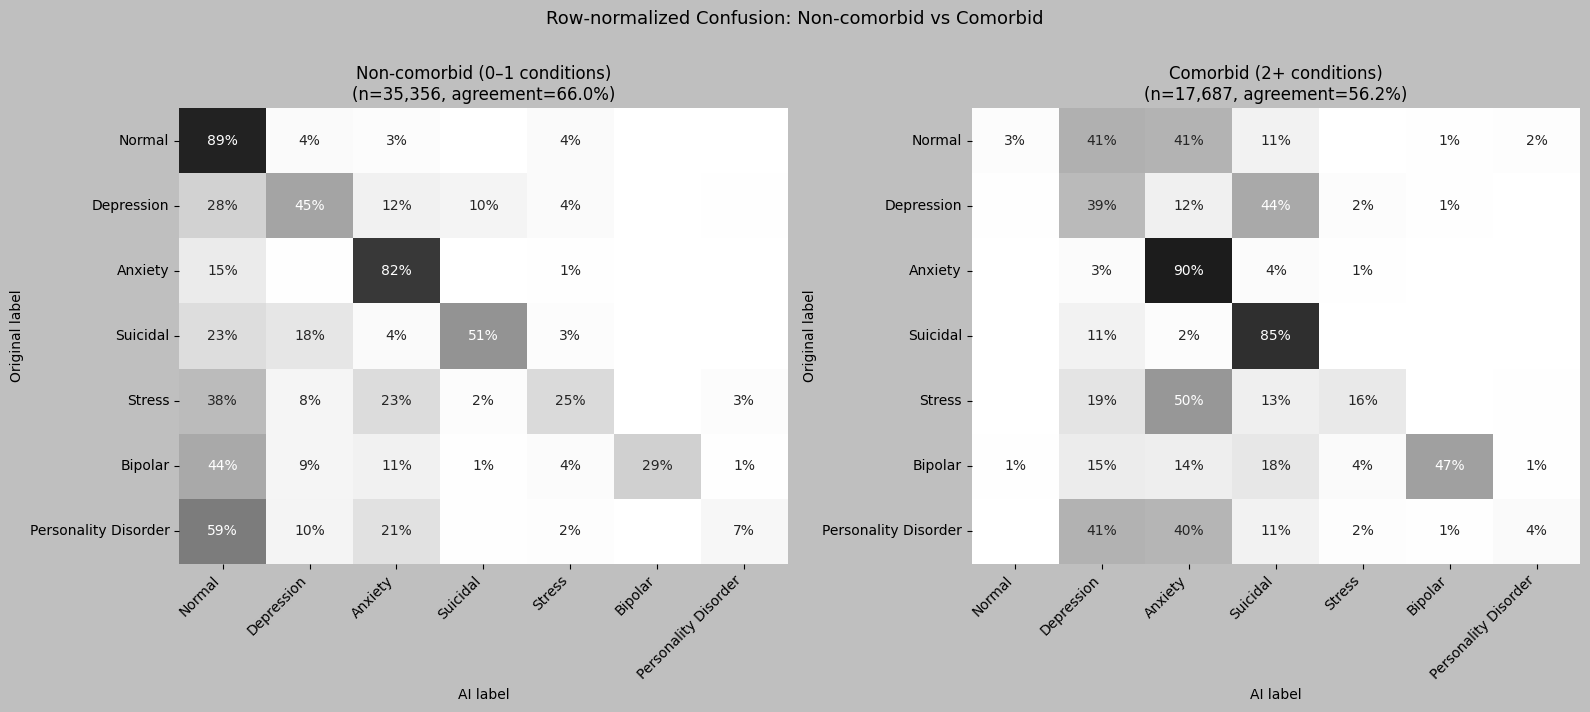

In [33]:
# --- 13c. Confusion matrix: comorbid vs non-comorbid ---
# Split the data and show confusion matrices side by side

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for idx, (label, mask) in enumerate([
    ("Non-comorbid (0–1 conditions)", df_valid["is_comorbid"] == 0),
    ("Comorbid (2+ conditions)", df_valid["is_comorbid"] == 1),
]):
    subset = df_valid[mask]
    cm = confusion_matrix(subset["human_label"], subset["ai_label"], labels=LABELS)
    # Normalize by row (original label)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    cm_pct = np.nan_to_num(cm_pct)

    annot = np.empty_like(cm, dtype=object)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f"{cm_pct[i,j]:.0%}" if cm_pct[i,j] >= 0.01 else ""

    ax = axes[idx]
    sns.heatmap(cm_pct, annot=annot, fmt="", cmap="Greys",
                xticklabels=LABELS, yticklabels=LABELS,
                vmin=0, vmax=1, ax=ax, cbar=False)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_xlabel("AI label")
    ax.set_ylabel("Original label")
    n_agree = (subset["human_label"] == subset["ai_label"]).sum()
    agree_pct = n_agree / len(subset) * 100
    ax.set_title(f"{label}\n(n={len(subset):,}, agreement={agree_pct:.1f}%)")

plt.suptitle("Row-normalized Confusion: Non-comorbid vs Comorbid", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "cm_comorbid_vs_noncomorbid.png"), dpi=300,
            bbox_inches="tight")
plt.show()

# 14. Comorbidity Motivates Soft Labels & Multi-Task Learning

=== Probability spread: comorbid vs non-comorbid ===
                   Non-comorbid (0-1)  Comorbid (2+)
n                          35356.0000     17687.0000
mean_entropy                   0.1896         0.3825
median_entropy                 0.0000         0.3251
mean_max_prob                  0.4345         0.8350
mean_sum_clinical              0.4712         1.0125
disagree_rate                  0.3401         0.4382

=== Detailed breakdown by number of conditions ===
            n  mean_entropy  mean_max_prob  mean_sum_clinical  disagree_rate
n_cond                                                                      
0       17463        0.1192         0.0324             0.0386         0.2449
1       17893        0.2584         0.8269             0.8934         0.4330
2       13514        0.3590         0.8426             1.0052         0.4222
3        3384        0.4393         0.8160             1.0275         0.4840
4         723        0.5439         0.7842             1.0716 

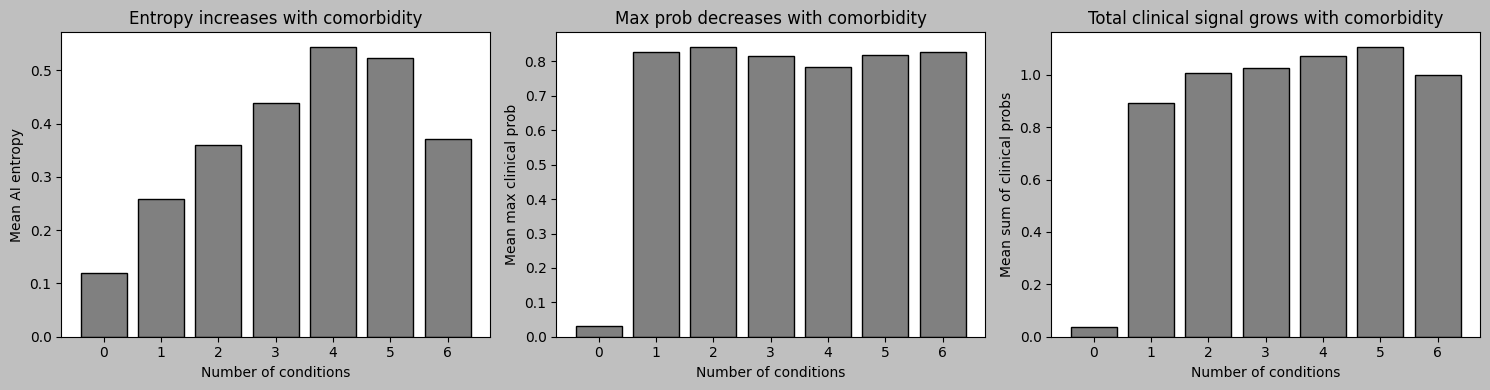

In [34]:
# --- 14a. Comorbidity → Soft probability spread ---
# Comorbid samples should have probability mass across multiple conditions
# Non-comorbid samples should have concentrated (one-hot-like) probability

# Metrics: entropy, max prob, sum of clinical probs
stats_by_comorbid = (
    df_valid.groupby("is_comorbid")
    .agg(
        n=("ai_entropy", "size"),
        mean_entropy=("ai_entropy", "mean"),
        median_entropy=("ai_entropy", "median"),
        mean_max_prob=("u_max_clinical_prob", "mean"),
        mean_sum_clinical=("u_sum_clinical_prob", "mean"),
        disagree_rate=("disagree", "mean"),
    )
    .round(4)
)
stats_by_comorbid.index = ["Non-comorbid (0-1)", "Comorbid (2+)"]
print("=== Probability spread: comorbid vs non-comorbid ===")
print(stats_by_comorbid.T)

# Same breakdown by n_conditions
print("\n=== Detailed breakdown by number of conditions ===")
stats_by_n = (
    df_valid.groupby("n_cond")
    .agg(
        n=("ai_entropy", "size"),
        mean_entropy=("ai_entropy", "mean"),
        mean_max_prob=("u_max_clinical_prob", "mean"),
        mean_sum_clinical=("u_sum_clinical_prob", "mean"),
        disagree_rate=("disagree", "mean"),
    )
    .round(4)
)
print(stats_by_n)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Entropy by n_conditions
axes[0].bar(stats_by_n.index, stats_by_n["mean_entropy"], edgecolor="black", color="0.5")
axes[0].set_xlabel("Number of conditions")
axes[0].set_ylabel("Mean AI entropy")
axes[0].set_title("Entropy increases with comorbidity")

# Max prob by n_conditions
axes[1].bar(stats_by_n.index, stats_by_n["mean_max_prob"], edgecolor="black", color="0.5")
axes[1].set_xlabel("Number of conditions")
axes[1].set_ylabel("Mean max clinical prob")
axes[1].set_title("Max prob decreases with comorbidity")

# Sum clinical prob by n_conditions
axes[2].bar(stats_by_n.index, stats_by_n["mean_sum_clinical"], edgecolor="black", color="0.5")
axes[2].set_xlabel("Number of conditions")
axes[2].set_ylabel("Mean sum of clinical probs")
axes[2].set_title("Total clinical signal grows with comorbidity")

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "comorbidity_soft_label_motivation.png"), dpi=300)
plt.show()

In [35]:
# --- 14b. Information lost by hard labels: comorbid examples ---
# Show a few concrete examples where hard label throws away comorbidity signal
print("=== Examples: comorbid samples where hard label loses information ===\n")

# Map prob columns to display names (all 7 including Normal)
PROB_DISPLAY = ["Normal", "Depression", "Anxiety", "Suicidal", "Stress", "Bipolar", "Pers. Disorder"]

# Comorbid, high entropy, disagreement
examples = df_valid[
    (df_valid["n_cond"] >= 2)
    & (df_valid["ai_entropy"] > 0.58)  # ~0.3 on normalized scale × ln(7)
    & (df_valid["disagree"] == 1)
].sort_values("ai_entropy", ascending=False).head(8)

for _, row in examples.iterrows():
    print(f"  Text:     {row[TEXT_COL][:100]}...")
    print(f"  Original: {row['human_label']}")
    print(f"  AI label: {row['ai_label']}")
    probs = {PROB_DISPLAY[i]: row[PROB_COLS[i]] for i in range(len(PROB_COLS))}
    nonzero = {k: f"{v:.2f}" for k, v in probs.items() if v > 0.01}
    print(f"  Probs:    {nonzero}")
    present = [CONDITION_NAMES[i] for i, col in enumerate(CONDITION_COLS) if row[col]]
    print(f"  Present:  {present}  (n_cond={row['n_cond']:.0f})")
    print(f"  Entropy:  {row['ai_entropy']:.3f}")
    print()

=== Examples: comorbid samples where hard label loses information ===

  Text:     Medical marijuana- does it help or hurt? I have a few diagnosed mental health conditions. I was diag...
  Original: Bipolar
  AI label: Personality Disorder
  Probs:    {'Normal': '0.10', 'Depression': '0.10', 'Anxiety': '0.20', 'Stress': '0.20', 'Bipolar': '0.20', 'Pers. Disorder': '0.20'}
  Present:  ['Anxiety', 'Stress', 'Bipolar', 'Pers. Disorder']  (n_cond=4)
  Entropy:  1.748

  Text:     A sustained loud noise like music doesn't bother me. Basically, I just scare very easily and have a ...
  Original: Normal
  AI label: Personality Disorder
  Probs:    {'Normal': '0.10', 'Depression': '0.10', 'Anxiety': '0.10', 'Stress': '0.10', 'Bipolar': '0.30', 'Pers. Disorder': '0.30'}
  Present:  ['Bipolar', 'Pers. Disorder']  (n_cond=2)
  Entropy:  1.643

  Text:     The isolation, the constant need of validation, comfort etc. I cannot just get these things, my depr...
  Original: Suicidal
  AI label: Person

=== Condition strength correlation matrix ===
                Depression  Anxiety  Suicidal  Stress  Bipolar  Pers. Disorder
Depression           1.000   -0.059     0.398   0.040    0.041           0.024
Anxiety             -0.059    1.000    -0.108   0.101    0.016           0.010
Suicidal             0.398   -0.108     1.000  -0.108   -0.032          -0.011
Stress               0.040    0.101    -0.108   1.000    0.002          -0.008
Bipolar              0.041    0.016    -0.032   0.002    1.000           0.041
Pers. Disorder       0.024    0.010    -0.011  -0.008    0.041           1.000


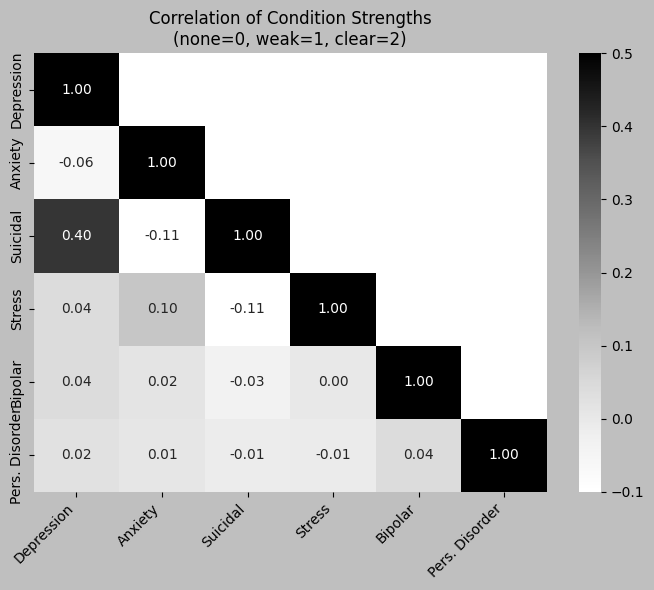


=== Top condition-pair correlations ===
Condition A    Condition B  Correlation
 Depression       Suicidal     0.398228
    Anxiety         Stress     0.101418
 Depression        Bipolar     0.041453
    Bipolar Pers. Disorder     0.040981
 Depression         Stress     0.040369
 Depression Pers. Disorder     0.023635
    Anxiety        Bipolar     0.015983
    Anxiety Pers. Disorder     0.009653
     Stress        Bipolar     0.001904
     Stress Pers. Disorder    -0.007797


In [36]:
# --- 14c. Multi-task justification: condition strength correlations ---
# If conditions co-occur and share textual signals, multi-task learning
# can leverage shared representations

STRENGTH_COLS = [
    "u_depression_strength", "u_anxiety_strength", "u_suicidal_strength",
    "u_stress_strength", "u_bipolar_strength", "u_personality_disorder_strength",
]
STRENGTH_MAP = {"none": 0, "weak": 1, "clear": 2}

# Encode strengths numerically
strength_numeric = df_valid[STRENGTH_COLS].copy()
for col in STRENGTH_COLS:
    strength_numeric[col] = strength_numeric[col].map(STRENGTH_MAP).fillna(0).astype(int)
strength_numeric.columns = CONDITION_NAMES

# Correlation matrix of condition strengths
corr = strength_numeric.corr()
print("=== Condition strength correlation matrix ===")
print(corr.round(3))

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Greys",
            mask=mask, vmin=-0.1, vmax=0.5, ax=ax)
ax.set_title("Correlation of Condition Strengths\n(none=0, weak=1, clear=2)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "condition_strength_correlation.png"), dpi=300)
plt.show()

# Highlight strongest correlations
print("\n=== Top condition-pair correlations ===")
corr_pairs = []
for i in range(len(CONDITION_NAMES)):
    for j in range(i+1, len(CONDITION_NAMES)):
        corr_pairs.append({
            "Condition A": CONDITION_NAMES[i],
            "Condition B": CONDITION_NAMES[j],
            "Correlation": corr.iloc[i, j],
        })
df_corr_pairs = pd.DataFrame(corr_pairs).sort_values("Correlation", ascending=False)
print(df_corr_pairs.head(10).to_string(index=False))

In [37]:
# --- 14d. Multilabel distribution ---
# u_multilabel contains the multi-label assignments (e.g., "DEPRESSION+ANXIETY")
print("=== Multi-label distribution ===")
ml_counts = df_valid["u_multilabel"].value_counts()
print(f"Unique multi-label patterns: {len(ml_counts)}")
print(f"\nTop 20 multi-label patterns:")
print(ml_counts.head(20).to_string())

# Single vs multi-label
is_multi = df_valid["u_multilabel"].str.contains(r"\+", na=False)
print(f"\n  Single-label:  {(~is_multi).sum()} ({(~is_multi).mean():.1%})")
print(f"  Multi-label:   {is_multi.sum()} ({is_multi.mean():.1%})")

# Disagreement rate for multi-label vs single-label
print(f"\n  Disagree rate (single-label): {df_valid.loc[~is_multi, 'disagree'].mean():.1%}")
print(f"  Disagree rate (multi-label):  {df_valid.loc[is_multi, 'disagree'].mean():.1%}")

=== Multi-label distribution ===
Unique multi-label patterns: 59

Top 20 multi-label patterns:
u_multilabel
NORMAL                                17463
DEPRESSION+SUICIDAL                    6918
DEPRESSION                             5434
ANXIETY                                4558
STRESS                                 3773
SUICIDAL                               3219
DEPRESSION+STRESS                      2113
ANXIETY+STRESS                         1717
DEPRESSION+ANXIETY                     1535
DEPRESSION+ANXIETY+SUICIDAL            1123
DEPRESSION+ANXIETY+STRESS               842
DEPRESSION+SUICIDAL+STRESS              650
BIPOLAR                                 543
DEPRESSION+ANXIETY+SUICIDAL+STRESS      380
DEPRESSION+BIPOLAR                      370
PERSONALITY_DISORDER                    366
ANXIETY+SUICIDAL                        185
DEPRESSION+PERSONALITY_DISORDER         169
DEPRESSION+SUICIDAL+BIPOLAR             156
DEPRESSION+ANXIETY+BIPOLAR              140

  Single-la

# 15. Comorbidity Summary

In [38]:
print("=" * 60)
print("COMORBIDITY ANALYSIS SUMMARY")
print("=" * 60)

n_total = len(df_valid)
n_comorbid = df_valid["is_comorbid"].sum()
n_multi = is_multi.sum()

print(f"\n--- Prevalence ---")
print(f"  Total samples:               {n_total}")
print(f"  Comorbid (2+ conditions):    {n_comorbid} ({n_comorbid/n_total:.1%})")
print(f"  Multi-label patterns:        {n_multi} ({n_multi/n_total:.1%})")
print(f"  Mean conditions per sample:  {df_valid['n_cond'].mean():.2f}")

print(f"\n--- Comorbidity → Label Confusion ---")
print(f"  Disagree rate (non-comorbid):  {df_valid.loc[df_valid['is_comorbid']==0, 'disagree'].mean():.1%}")
print(f"  Disagree rate (comorbid):      {df_valid.loc[df_valid['is_comorbid']==1, 'disagree'].mean():.1%}")
print(f"  → Comorbid samples are ~{df_valid.loc[df_valid['is_comorbid']==1, 'disagree'].mean() / df_valid.loc[df_valid['is_comorbid']==0, 'disagree'].mean():.1f}x more likely to have human–AI disagreement")

print(f"\n--- Implications for Training Strategy ---")
print(f"  1. SOFT LABELS: Comorbid samples have mean entropy "
      f"{df_valid.loc[df_valid['is_comorbid']==1, 'ai_entropy'].mean():.3f} "
      f"vs {df_valid.loc[df_valid['is_comorbid']==0, 'ai_entropy'].mean():.3f} "
      f"for non-comorbid.")
print(f"     Hard one-hot labels discard this uncertainty → soft probability")
print(f"     distributions preserve clinically meaningful comorbidity signal.")
print(f"  2. MULTI-TASK: Conditions co-occur (e.g., Depression–Suicidal,")
print(f"     Depression–Anxiety) → shared textual features can be learned")
print(f"     jointly via multi-task heads for per-condition strength.")
print(f"  3. CONFUSION MATRIX: Top confusion pairs (Depression↔Suicidal,")
print(f"     Depression↔Anxiety) align with highest comorbidity rates,")
print(f"     suggesting disagreement reflects genuine clinical overlap,")
print(f"     not annotation noise.")

COMORBIDITY ANALYSIS SUMMARY

--- Prevalence ---
  Total samples:               53043
  Comorbid (2+ conditions):    17687 (33.3%)
  Multi-label patterns:        17687 (33.3%)
  Mean conditions per sample:  1.10

--- Comorbidity → Label Confusion ---
  Disagree rate (non-comorbid):  34.0%
  Disagree rate (comorbid):      43.8%
  → Comorbid samples are ~1.3x more likely to have human–AI disagreement

--- Implications for Training Strategy ---
  1. SOFT LABELS: Comorbid samples have mean entropy 0.382 vs 0.190 for non-comorbid.
     Hard one-hot labels discard this uncertainty → soft probability
     distributions preserve clinically meaningful comorbidity signal.
  2. MULTI-TASK: Conditions co-occur (e.g., Depression–Suicidal,
     Depression–Anxiety) → shared textual features can be learned
     jointly via multi-task heads for per-condition strength.
  3. CONFUSION MATRIX: Top confusion pairs (Depression↔Suicidal,
     Depression↔Anxiety) align with highest comorbidity rates,
     sug